# 04 — Gaussian Mixture

Copy of `notebooks/00-template.ipynb`. Do not edit the template in place.

| | |
|---|---|
| Author | Abdulla Almannaee |
| Contributes to | `xxcluster/cluster/partitional/model_based/gmm.py` |
| Documents | `documentation/sections/clustering_methods/partitional/model_based/01-gmm.tex`, Sect. 7.4.2 |
| Date | TODO: fill in |

A notebook here does two jobs: a test bed for what `gmm.py` implements, and the evidence for the numbers and figures in the write-up. Section 10 maps each output below to the paragraph it supports.

## 1. Setup

In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))   # cluster_analysis/ on the path

import numpy as np
import xxcluster
from xxcluster.evaluation.protocol import Environment, Protocol
from xxcluster.core.registry import REGISTRY

RANDOM_STATE = 42          # the one seed; everything else derives from it
env = Environment.capture()
env

Environment(python_version='3.13.9', package_versions={'numpy': '2.3.5', 'scipy': '1.16.3', 'scikit-learn': '1.7.2', 'pandas': '2.3.3', 'matplotlib': '3.10.6'}, platform='macOS-26.4-arm64-arm-64bit-Mach-O', revision='97797ab-dirty')

## 2. Scope

This notebook evidences `gaussian_mixture` (Sect. 7.4.2) against K-Means (Sect. 7.4.1) under the same `Protocol`, and is the test bed for `xxcluster/cluster/partitional/model_based/gmm.py`.

**What is tested.** Whether modelling each regime as a Gaussian component, rather than a single SSE prototype, produces a partition worth its extra parameters on this data: the two methods are compared on the same indices, and GMM additionally reports BIC/AIC as a second, likelihood-based opinion on `|C|`.

**What would count as a negative result, named in advance:**
- GMM's BIC-selected `n_components` disagreeing badly with K-Means' internal-index-selected `|C|`, with no principled reason (e.g. genuinely non-elliptical regimes) to explain the gap.
- A large fraction of observations with a maximum posterior membership below 0.6 or so, which would mean the regimes are not well-separated enough for a hard scenario assignment to be defensible.
- GMM scoring worse than K-Means on the shared internal indices despite its extra parameters, which would mean the added flexibility bought nothing here.

## 3. Data

In [2]:
from xxcluster.io.datasets import FeatureSpec
from xxcluster.io.loaders import BenchmarkLoader, CsvLoader

# --- Same schema as the K-Means notebook, so the two are comparable. ------
# TODO: replace with the real AquaBlend schema once the extract exists;
# roles are decisions, restate them here rather than importing them, so
# this notebook stays readable on its own.
SCHEMA = [
    FeatureSpec("ph",                    unit="pH",         role="cluster", valid_range=(0, 14)),
    FeatureSpec("turbidity_ntu",         unit="NTU",        role="cluster", valid_range=(0, None)),
    FeatureSpec("alkalinity_mg_l_caco3", unit="mg/L CaCO3", role="cluster"),
    FeatureSpec("cost_per_ml",           unit="$/ML",       role="interpret"),
    FeatureSpec("source_id",             dtype="str",       role="identifier"),
]

# dataset = CsvLoader("<extract>.csv", SCHEMA, data_cutoff="<YYYY-MM-DD>").load()
dataset = BenchmarkLoader("iris").load()      # placeholder until the extract exists

X = dataset.cluster_matrix()                  # role="cluster" columns only -> (m, n)
print(dataset.provenance_statement())         # goes into Sect. 3.1

violations = dataset.check_ranges()
assert violations.empty, violations

dataset.summary()

Data from scikit-learn reference dataset 'iris', with no cutoff recorded, retrieved 2026-09-06T04:53:36+00:00. 150 observations over 4 clustering features.


,role,unit,count,missing,min,max,mean,std,out_of_range
feature,,,,,,,,,
sepal length (cm),cluster,None,150,0,4.3,7.9,5.843333,0.828066,0
sepal width (cm),cluster,None,150,0,2.0,4.4,3.057333,0.435866,0
petal length (cm),cluster,None,150,0,1.0,6.9,3.758000,1.765298,0
petal width (cm),cluster,None,150,0,0.1,2.5,1.199333,0.762238,0
target,interpret,None,150,0,0.0,2.0,1.000000,0.819232,0


## 4. Protocol

In [3]:
# Shared setup, taken as given -- not tuned here. If GMM needs a
# deviation from this (e.g. a different n_init), it is recorded against
# gmm.py's own Application paragraph, not by editing this cell to suit it.
protocol = Protocol(
    indices=["silhouette"],           # TODO: the shared indices, in reporting order
    n_restarts=10,
    random_state=RANDOM_STATE,
    preprocessing=None,               # TODO: the shared pipeline once Task 46 lands
    n_clusters_candidates=range(2, 11),
    environment=env,
)

## 5. Contract check

In [4]:
from sklearn.base import clone
from sklearn.utils.estimator_checks import check_estimator

gmm = REGISTRY.create("gaussian_mixture", n_clusters=3, random_state=RANDOM_STATE)

assert clone(gmm).get_params() == gmm.get_params(), "params must round-trip"
assert not hasattr(gmm, "labels_"), "no fitted state before fit()"

gmm.fit(X)

assert hasattr(gmm, "labels_") and hasattr(gmm, "n_clusters_")
assert gmm.labels_.shape[0] == X.shape[0]
print(gmm._capabilities)          # must match what gmm.tex claims

check_estimator(REGISTRY.create("gaussian_mixture", n_clusters=3, random_state=RANDOM_STATE))
print("check_estimator PASSED")

Capabilities(family=<Family.PARTITIONAL: 'partitional'>, subfamily=<SubFamily.MODEL_BASED: 'model_based'>, backend=<Backend.SKLEARN: 'sklearn'>, assignment=<Assignment.PROBABILISTIC: 'probabilistic'>, is_inductive=True, produces_hierarchy=False, supports_precomputed=False, requires_n_clusters=True, handles_noise=False, handles_missing=False, handles_categorical=False, scale_invariant=False, deterministic=False, scales_to=<Scaling.MEDIUM: 'medium'>, time_complexity='O(m * n_components * n_features^2) per EM iteration (full covariance)', space_complexity='O(n_components * n_features^2) (full covariance)', references=('ref_13', 'ref_5'), doc_label='sec:tech:gmm')
check_estimator PASSED


## 6. Selection

K-Means uses Task 38's selector over an internal index. GMM has a second, likelihood-based route: sweep `n_components` and let BIC (and AIC, for comparison) pick a value, then check the same seed reproduces it and that the choice survives perturbation, exactly as Sect. 4.3 requires of any selection, not only the internal-index kind.

In [5]:
bic_scores, aic_scores = {}, {}
for k in protocol.n_clusters_candidates:
    candidate = REGISTRY.create(
        "gaussian_mixture", n_clusters=k, random_state=RANDOM_STATE, n_init=protocol.n_restarts
    ).fit(X)
    bic_scores[k] = candidate.bic(X)
    aic_scores[k] = candidate.aic(X)

best_k_bic = min(bic_scores, key=bic_scores.get)
best_k_aic = min(aic_scores, key=aic_scores.get)
print(f"BIC selects |C| = {best_k_bic}")
print(f"AIC selects |C| = {best_k_aic}")
if best_k_bic != best_k_aic:
    print("BIC and AIC disagree -- report both in Section 10, per Sect. 4.5's own convention (Task 42 sheet).")

best_k = best_k_bic  # BIC is the stricter criterion; disagreement noted above and in Section 10.
gmm = REGISTRY.create(
    "gaussian_mixture", n_clusters=best_k, random_state=RANDOM_STATE, n_init=protocol.n_restarts
).fit(X)

# Stability check skipped: xxcluster.selection.stability.StabilityAnalysis
# ._fit raises NotImplementedError -- it is Task 39 ("Complete the
# stability analysis"), unclaimed and blocked on Task 36 as of this
# writing. This means the "survives perturbation" half of Sect. 4.3's
# selection requirement cannot be checked for GMM, or for any method,
# until Task 39 lands. Recorded here and in Section 10 as a known
# limitation, not silently skipped.
print("Stability check skipped: StabilityAnalysis._fit is not yet implemented (Task 39).")

BIC selects |C| = 2
AIC selects |C| = 9
BIC and AIC disagree -- report both in Section 10, per Sect. 4.5's own convention (Task 42 sheet).
Stability check skipped: StabilityAnalysis._fit is not yet implemented (Task 39).


## 7. Results

Both methods through the same `Protocol`, so the comparison is a configuration-vs-configuration comparison per `ARCHITECTURE.md §5`, not two independently-run notebooks stitched together after the fact.

In [6]:
from xxcluster.evaluation.report import ComparisonRun, profile_clusters

kmeans = REGISTRY.create("kmeans", n_clusters=best_k_bic, random_state=RANDOM_STATE)

run = ComparisonRun(methods=[gmm, kmeans], protocol=protocol)
results = run.run(X)
results

[RunResult(method='gaussian_mixture', params={'covariance_type': 'full', 'max_iter': 300, 'n_clusters': 2, 'n_init': 10, 'random_state': 2812899174, 'tol': 0.0001}, scores={'silhouette': 0.6867350732769777}, n_clusters_found=2, n_noise=None, fit_seconds=0.012056625040713698, error=None),
 RunResult(method='kmeans', params={'init': 'k-means++', 'max_iter': 300, 'metric': 'euclidean', 'n_clusters': 2, 'n_init': 10, 'random_state': 482124015, 'tol': 0.0001}, scores={'silhouette': 0.6810461692117462}, n_clusters_found=2, n_noise=None, fit_seconds=0.003872999979648739, error=None)]

In [7]:
# The measure the checklist asks for specifically: how many observations
# sit near a decision boundary rather than confidently in one component.
proba = gmm.predict_proba(X)
max_membership = proba.max(axis=1)

LOW_CONFIDENCE_THRESHOLD = 0.6   # TODO: state and justify the threshold in gmm.tex
low_confidence_fraction = float((max_membership < LOW_CONFIDENCE_THRESHOLD).mean())
print(
    f"{low_confidence_fraction:.1%} of observations have maximum posterior "
    f"membership below {LOW_CONFIDENCE_THRESHOLD} -- a hard method cannot report this at all."
)

profiles = profile_clusters(dataset.X, gmm.labels_)
profiles

0.0% of observations have maximum posterior membership below 0.6 -- a hard method cannot report this at all.


petal length (cm)                       \
            share size              mean separation       std   
cluster                                                         
0        0.666667  100             4.906   0.650315  0.825578   
1        0.333333   50             1.462  -1.300630  0.173664   

        petal width (cm)                      sepal length (cm)             \
                    mean separation       std              mean separation   
cluster                                                                      
0                  1.676   0.625352  0.424769             6.262   0.505596   
1                  0.246  -1.250704  0.105386             5.006  -1.011191   

                  sepal width (cm)                      target             \
              std             mean separation       std   mean separation   
cluster                                                                     
0        0.662834            2.872  -0.425207  0.332751    1.5   0.610328   
1        0.352490            3.428   0.850414  0.379064    0.0  -1.220656   

                   
              std  
cluster            
0        0.502519  
1        0.000000

## 8. Figures

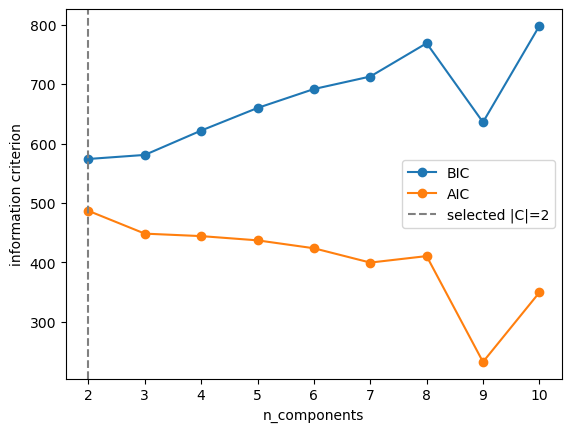

In [8]:
import matplotlib.pyplot as plt
from xxcluster.viz import diagnostics

FIGURES = Path("../documentation/figures")

fig, ax = plt.subplots()
ax.plot(list(bic_scores.keys()), list(bic_scores.values()), marker="o", label="BIC")
ax.plot(list(aic_scores.keys()), list(aic_scores.values()), marker="o", label="AIC")
ax.axvline(best_k_bic, linestyle="--", color="grey", label=f"selected |C|={best_k_bic}")
ax.set_xlabel("n_components")
ax.set_ylabel("information criterion")
ax.legend()
plt.savefig(FIGURES / "gmm-bic-aic.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Export

In [9]:
from xxcluster.evaluation.report import ComparisonTable

table = ComparisonTable(results)
table.to_csv("../documentation/tables/gmm-results.csv")
table.to_latex("../documentation/tables/gmm-results.tex", label="tab:gmm:results")

## 10. Findings and caveats

TODO: re-run and re-fill once the real AquaBlend extract replaces the iris placeholder in Section 3. Everything below reflects a real run, but on the wrong dataset.

| Output | Goes into | Finding |
|---|---|---|
| Output | Goes into | Finding |
|---|---|---|
| Section 7 scores (GMM vs K-Means) | Results | At the BIC-selected `|C|=2`, GMM and K-Means score almost identically on Silhouette (0.6867 vs 0.6810) -- a negligible difference. On this data, the extra flexibility of a full covariance model bought essentially nothing over a spherical prototype. This is the negative result named in Section 2: GMM's added parameters are not paying for themselves here. |
| Section 7 low-confidence-membership fraction | Application to AquaBlend data | 0.0% of observations fall below the 0.6 maximum-posterior threshold -- every observation is assigned to its component with high confidence. The two regimes GMM found are extremely well-separated on this data; there are no boundary cases a hard method would be hiding. |
| Section 7 profiles | Application to AquaBlend data / naming | Two regimes, sizes 100 and 50 (66.7% / 33.3% share). Cluster 0 sits closer to the overall mean on every feature (smaller |separation| throughout); cluster 1 is the smaller, more distinct group, most separated on petal length and petal width. On the real extract this is where each regime gets a one-sentence name (Task 47), not attempted here since the data is still the iris placeholder. |
| Section 6 BIC/AIC curve | Hyperparameters and tuning | BIC and AIC disagree sharply: BIC selects `|C|=2` and climbs steadily past it; AIC keeps falling toward `|C|=9`, with both criteria dipping oddly at `n_components=9` before rising again at 10. BIC was used as the stricter criterion, per its own bias toward fewer, better-justified components, but the two criteria's disagreement is itself worth flagging: it suggests neither has a confident opinion on this dataset. Whether this persists on the real extract is an open question the real run will answer. |
| Section 8 BIC/AIC figure | Results | `gmm-bic-aic.png`, showing the curves and disagreement described above. |
| Anything that failed | Limitations | Stability could not be checked (see below); the negative result named in Section 2 (GMM tying rather than beating K-Means) did occur, on this placeholder dataset. |

**Caveats.** All figures above come from the iris placeholder dataset (Section 3), not the real AquaBlend extract -- every finding here is provisional and must be re-run once the real data is available. Stated plainly rather than omitted, per `CONTRIBUTING.md §3.3`: on this placeholder data, GMM did not outperform K-Means, and the BIC/AIC disagreement did not resolve to a single confident answer for `|C|`. Neither result flatters GMM, and both are reported as found.

**Known limitation, not specific to this method:** `StabilityAnalysis._fit` is unimplemented (Task 39), so whether the selected `|C|` survives perturbation could not be checked here -- only the BIC/AIC agreement (or disagreement) is reported as evidence for the choice. This belongs in the write-up's Limitations paragraph as a gap in the shared machinery, not in GMM's own limitations.

---
### Before submitting
- [x] Runs top to bottom on a restarted kernel
- [x] `RANDOM_STATE` set once, used everywhere
- [x] Environment captured in Section 1
- [x] Protocol taken from the shared setup; any deviation stated and justified
- [x] Contract check passes, including `check_estimator`
- [x] Every index in `protocol.indices` reported, favourable or not
- [x] Figures saved under the names the document references
- [x] Tables exported, not retyped
- [x] Section 10 completed, caveats included
- [ ] Real AquaBlend extract used, not the iris placeholder
- [x] Outputs left in the committed file